In [10]:
import pandas as pd
import numpy as np

In [11]:
gemini_data = pd.read_csv("gemini_results_20241024temperature_0_n_repeats_10.csv", header=0, sep=",")

In [12]:
aug_rates = gemini_data["augmentation_rate"].unique().tolist()
means = []
vars = [] # variances
lows = [] # lower bound of confidence interval
highs = [] # upper bound of confidence interval

for aug_rate in aug_rates:
    values = gemini_data[gemini_data["augmentation_rate"] == aug_rate]["code_similarity"].tolist()
    mean = np.mean(values)
    variance = np.var(values)
    std = np.std(values)
    ci = 1.96 * std / np.sqrt(len(values))

    means.append(mean)
    vars.append(variance)
    lows.append(mean - ci)
    highs.append(mean + ci)

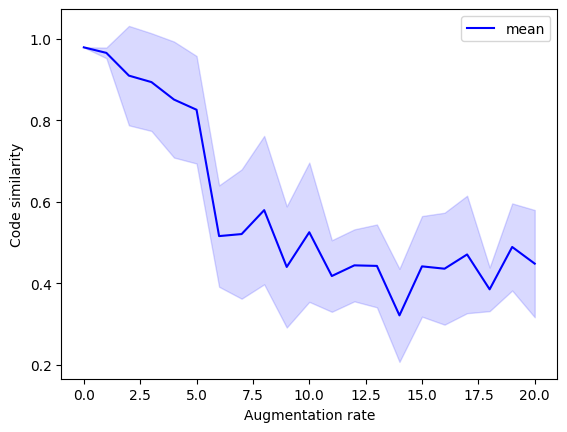

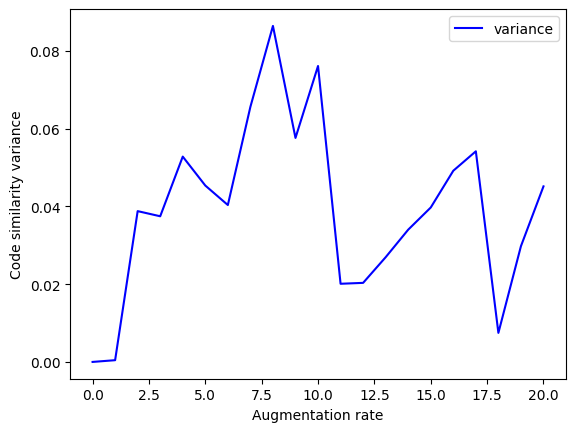

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(means,'-b', label='mean')
plt.fill_between(list(range(len(means))), lows, highs, color="b", alpha=0.15)
plt.xlabel("Augmentation rate")
plt.ylabel("Code similarity")
plt.legend();


plt.figure()
plt.plot(vars,'-b', label='variance')
plt.xlabel("Augmentation rate")
plt.ylabel("Code similarity variance")
plt.legend();
